# Prosody transfer between Kokoro voices: pitch, energy, duration

The **target** voice gives the timbre. Any combination of prosody can come from the **donor** voice:

| what | how it is transferred | normalization |
|---|---|---|
| duration | donor's per-phoneme durations | optional: rescale to the target's total length (keep donor rhythm, target tempo) |
| pitch (F0) | donor's F0 contour | log-F0 z-score on voiced frames → target's mean (and range) |
| energy (N) | donor's energy contour | z-score (N is already log-like) → target's mean (and range) |

Whatever is *not* transferred comes from the target's own prediction. Pitch and energy are always predicted on the same alignment, so the curves stay frame-aligned.

In [1]:
from functions import * 
from functions import  _voice_pack, _encode,   predict_durations   , align_phonemes   # model, g2p, _encode, _voice_pack, predict_durations, align_phonemes, SR, FRAME_SAMPLES
import torch, numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Audio

c:\Users\utente\anaconda3\envs\koko\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\utente\anaconda3\envs\koko\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(
c:\Users\utente\anaconda3\envs\koko\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


## Model helpers

In [2]:
@torch.no_grad()
def make_alignment(ps, dur):
    """Token-to-frame alignment matrix (1, n_tokens, n_frames) from durations."""
    dev = model.device
    n = _encode(ps)["n"]
    dur = torch.as_tensor(dur, device=dev).long().clamp(min=0).reshape(-1)
    assert dur.shape[0] == n, f"durations ({dur.shape[0]}) != tokens incl. BOS/EOS ({n})"
    idx = torch.repeat_interleave(torch.arange(n, device=dev), dur)
    aln = torch.zeros((n, idx.shape[0]), device=dev)
    aln[idx, torch.arange(idx.shape[0], device=dev)] = 1
    return aln.unsqueeze(0)


@torch.no_grad()
def predict_f0n(ps, pack, aln):
    """Predicted F0 (Hz) and energy N of voice `pack` on the given alignment, as numpy (2*n_frames,)."""
    enc = _encode(ps)
    s = pack[len(ps) - 1][:, 128:]
    d = model.predictor.text_encoder(enc["d_en"], s, enc["L"], enc["tm"])
    F0, N = model.predictor.F0Ntrain(d.transpose(-1, -2) @ aln, s)
    return F0.squeeze().cpu().numpy(), N.squeeze().cpu().numpy()


@torch.no_grad()
def decode(ps, pack, aln, f0, n):
    """Decoder with voice `pack`'s timbre and the GIVEN F0 / energy curves (numpy)."""
    enc = _encode(ps)
    ref_s = pack[len(ps) - 1]
    to_t = lambda x: torch.as_tensor(x, dtype=torch.float32, device=model.device).unsqueeze(0)
    return model.decoder(enc["t_en"] @ aln, to_t(f0), to_t(n), ref_s[:, :128]).squeeze().cpu().numpy()

## Normalization

In [3]:
VOICED_HZ = 50.0   # absolute floor for voiced F0

def voiced_mask(f0, thr=VOICED_HZ, rel=0.6):
    """Voiced = above thr AND above rel * the voice's median pitch.
    Drops the half-voiced frames at voicing on/offsets."""
    v = f0 > thr
    return v & (f0 > rel * np.median(f0[v]))

def _z_transfer(x_donor, x_target, mask_d, mask_t, mode):
    """Move x_donor (on mask_d) into x_target's statistics (on mask_t)."""
    mu_d, sd_d = x_donor[mask_d].mean(), x_donor[mask_d].std()
    mu_t, sd_t = x_target[mask_t].mean(), x_target[mask_t].std()
    z = x_donor - mu_d
    if mode == "meanstd":
        z = z / (sd_d + 1e-8) * sd_t
    elif mode == "raw":
        return x_donor.copy()
    return z + mu_t


def normalize_f0(f0_d, f0_t, mode="meanstd", thr=VOICED_HZ):
    """Donor's F0 shape in the target's register (log domain, voiced frames).
    mode: "raw" (no normalization), "mean" (shift only), "meanstd" (shift + range).
    Unvoiced frames keep the donor's values -> voicing follows the donor."""
    vd, vt = voiced_mask(f0_d, thr), voiced_mask(f0_t, thr)
    out = f0_d.copy()
    lf = _z_transfer(np.log(np.maximum(f0_d, 1e-3)), np.log(np.maximum(f0_t, 1e-3)), vd, vt, mode)
    out[vd] = np.exp(lf[vd])
    return out


def normalize_energy(n_d, n_t, mode="meanstd"):
    """Donor's energy shape at the target's level. Kokoro's N is already log-like,
    so a linear z-score is used. Stats on all frames."""
    all_d, all_t = np.ones_like(n_d, bool), np.ones_like(n_t, bool)
    return _z_transfer(n_d, n_t, all_d, all_t, mode)


def normalize_durations(dur_d, dur_t, mode="rate"):
    """mode "raw":  donor durations as they are (donor rhythm AND tempo).
            "rate": rescale so the total equals the target's (donor rhythm, target tempo).
    Rounding is done on the cumulative sum, so the total is exact and nothing drifts."""
    dur_d = np.asarray(dur_d, float)
    if mode == "raw":
        return dur_d.astype(int).tolist()
    scaled = dur_d * (sum(dur_t) / dur_d.sum())
    edges = np.round(np.concatenate([[0], np.cumsum(scaled)])).astype(int)
    return np.maximum(np.diff(edges), 1).tolist()

## Transfer function

In [4]:
def prosody_transfer(ps, target_voice, donor_voice,
                     pitch=True, energy=True, duration=False,
                     f0_mode="meanstd", energy_mode="meanstd", dur_mode="rate"):
    """Target timbre + any mix of the donor's pitch / energy / duration.
    Returns (audio, info dict with all curves for plotting)."""
    tpack, _ = _voice_pack(target_voice)
    dpack, _ = _voice_pack(donor_voice)

    dur_t = predict_durations(ps, tpack)
    dur_d = predict_durations(ps, dpack)
    dur = normalize_durations(dur_d, dur_t, dur_mode) if duration else dur_t
    aln = make_alignment(ps, dur)

    # both voices predicted on the SAME alignment -> frame-aligned curves
    f0_t, n_t = predict_f0n(ps, tpack, aln)
    f0_d, n_d = predict_f0n(ps, dpack, aln)

    f0 = normalize_f0(f0_d, f0_t, f0_mode)       if pitch  else f0_t
    n  = normalize_energy(n_d, n_t, energy_mode) if energy else n_t

    audio = decode(ps, tpack, aln, f0, n)
    info = dict(ps=ps, dur=dur, dur_t=dur_t, dur_d=dur_d,
                f0=f0, f0_t=f0_t, f0_d=f0_d, n=n, n_t=n_t, n_d=n_d,
                target=target_voice, donor=donor_voice,
                what=[k for k, v in [("pitch", pitch), ("energy", energy), ("duration", duration)] if v])
    return audio, info


def natural(ps, voice):
    """Voice with its own prosody (reference for listening)."""
    pack, _ = _voice_pack(voice)
    dur = predict_durations(ps, pack)
    aln = make_alignment(ps, dur)
    return decode(ps, pack, aln, *predict_f0n(ps, pack, aln))

## Plot

In [5]:
def _stats_line(name, f0, n, dur):
    v = f0[voiced_mask(f0)]
    return (f"{name:12s} F0 {np.exp(np.log(v).mean()):6.1f} Hz  ±{12*np.log2(np.e)*np.log(v).std():4.1f} st   "
            f"energy {n.mean():6.2f} ±{n.std():5.2f}   length {sum(dur)*FRAME_SAMPLES/SR:5.2f} s")


def plot_transfer(info, audio, grid=False):
    nan = lambda x, m: np.where(m, x, np.nan)
    f0_t, f0_d, f0 = info["f0_t"], info["f0_d"], info["f0"]
    t = np.arange(len(f0)) * (FRAME_SAMPLES / 2) / SR          # F0/N frame = half a duration frame
    segs, _, _ = align_phonemes(info["ps"], info["dur"], n_samples=len(audio))

    fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=False)
    T, D, O = dict(label=f"target ({info['target']})", alpha=.7), dict(label=f"donor ({info['donor']})", alpha=.7), \
              dict(label="output", lw=2, color="k")

    ax = axes[0]                                                # raw F0
    for f, kw in [(f0_t, T), (f0_d, D), (f0, O)]:
        ax.plot(t, nan(f, voiced_mask(f)), **kw)
    ax.set_ylabel("F0 (Hz)"); ax.set_title("Pitch (raw)"); ax.legend(loc="upper right")

    ax = axes[1]                                                # F0 shape
    for f, kw in [(f0_t, T), (f0_d, D), (f0, {**O, "ls": "--"})]:
        lf = np.log(np.maximum(f, 1e-3)); v = voiced_mask(f)
        ax.plot(t, nan((lf - lf[v].mean()) / lf[v].std(), v), **kw)
    ax.set_ylabel("z(log F0)"); ax.set_title("Pitch shape (register removed)")

    ax = axes[2]                                                # energy
    for x, kw in [(info["n_t"], T), (info["n_d"], D), (info["n"], O)]:
        ax.plot(t, x, **kw)
    ax.set_ylabel("N"); ax.set_title("Energy")

    for ax in axes[:3]:                                         # phoneme grid on the time plots
        ax.set_xlim(0, t[-1])
        if grid:
            for lab, s, e, inf in segs:
                ax.axvline(s, color="gray", lw=.4, alpha=.4)
    for lab, s, e, inf in segs:
        if inf["kind"] == "phone":
            axes[0].text((s + e) / 2, axes[0].get_ylim()[1], lab, ha="center", va="bottom", fontsize=9)
    axes[2].set_xlabel("time (s)")

    ax = axes[3]                                                # durations per token, in ms
    labels = ["BOS"] + [c for c in info["ps"] if c in VOCAB] + ["EOS"]
    x = np.arange(len(labels)); w = .28; ms = 1000 * FRAME_SAMPLES / SR
    ax.bar(x - w, np.array(info["dur_t"]) * ms, w, label="target")
    ax.bar(x,     np.array(info["dur_d"]) * ms, w, label="donor")
    ax.bar(x + w, np.array(info["dur"])   * ms, w, label="output", color="k")
    ax.set_xticks(x); ax.set_xticklabels([LABEL_DISPLAY.get(l, l) for l in labels], fontsize=8)
    ax.set_ylabel("ms"); ax.set_title("Durations per token"); ax.legend(loc="upper right")

    fig.suptitle(f"{info['target']} with {info['donor']}'s " + (" + ".join(info["what"]) or "nothing"), fontsize=13)
    plt.tight_layout(); plt.show()

    print(_stats_line("target", f0_t, info["n_t"], info["dur_t"]))
    print(_stats_line("donor",  f0_d, info["n_d"], info["dur_d"]))
    print(_stats_line("output", f0,   info["n"],   info["dur"]))

## Settings

In [6]:
text         = "Oggi il tempo è bellissimo, andiamo al mare?"
target_voice = "im_nicola"    # timbre + register of the output
donor_voice  = "hf_alpha"      # where the prosody comes from

ps = text_to_ipa_chunks(text)[0]           # one sentence for simplicity
print(ps)

print("target (natural)"); display(Audio(natural(ps, target_voice), rate=SR))
print("donor (natural)");  display(Audio(natural(ps, donor_voice),  rate=SR))

ˈɔʤːɪ il tˈɛmpo e bellˈiSimo, andjˈamo al mˈare?
target (natural)


donor (natural)


## 1) Pitch + energy

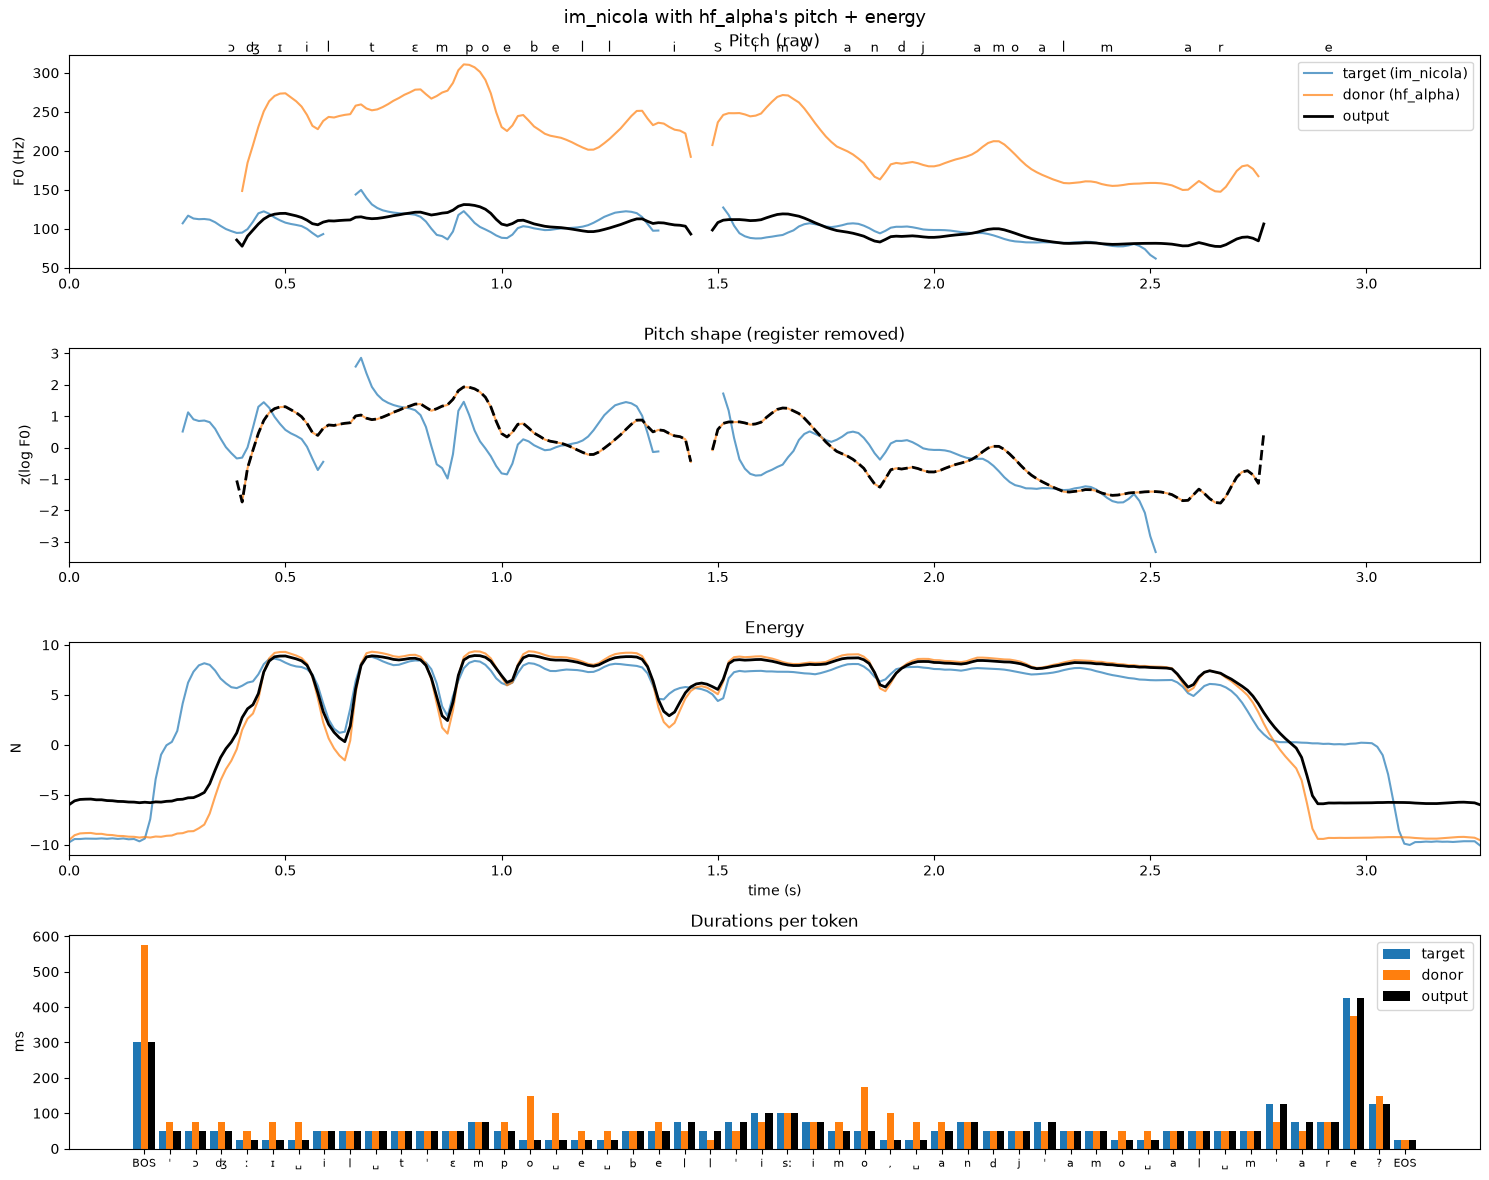

target       F0   99.5 Hz  ± 2.5 st   energy   4.04 ± 5.68   length  3.27 s
donor        F0  210.7 Hz  ± 3.5 st   energy   3.16 ± 7.19   length  4.17 s
output       F0   99.4 Hz  ± 2.5 st   energy   4.04 ± 5.68   length  3.27 s


In [7]:
audio_pe, info_pe = prosody_transfer(ps, target_voice, donor_voice,
                                     pitch=True, energy=True, duration=False)
display(Audio(audio_pe, rate=SR))
plot_transfer(info_pe, audio_pe)

## 2) Pitch + energy + duration

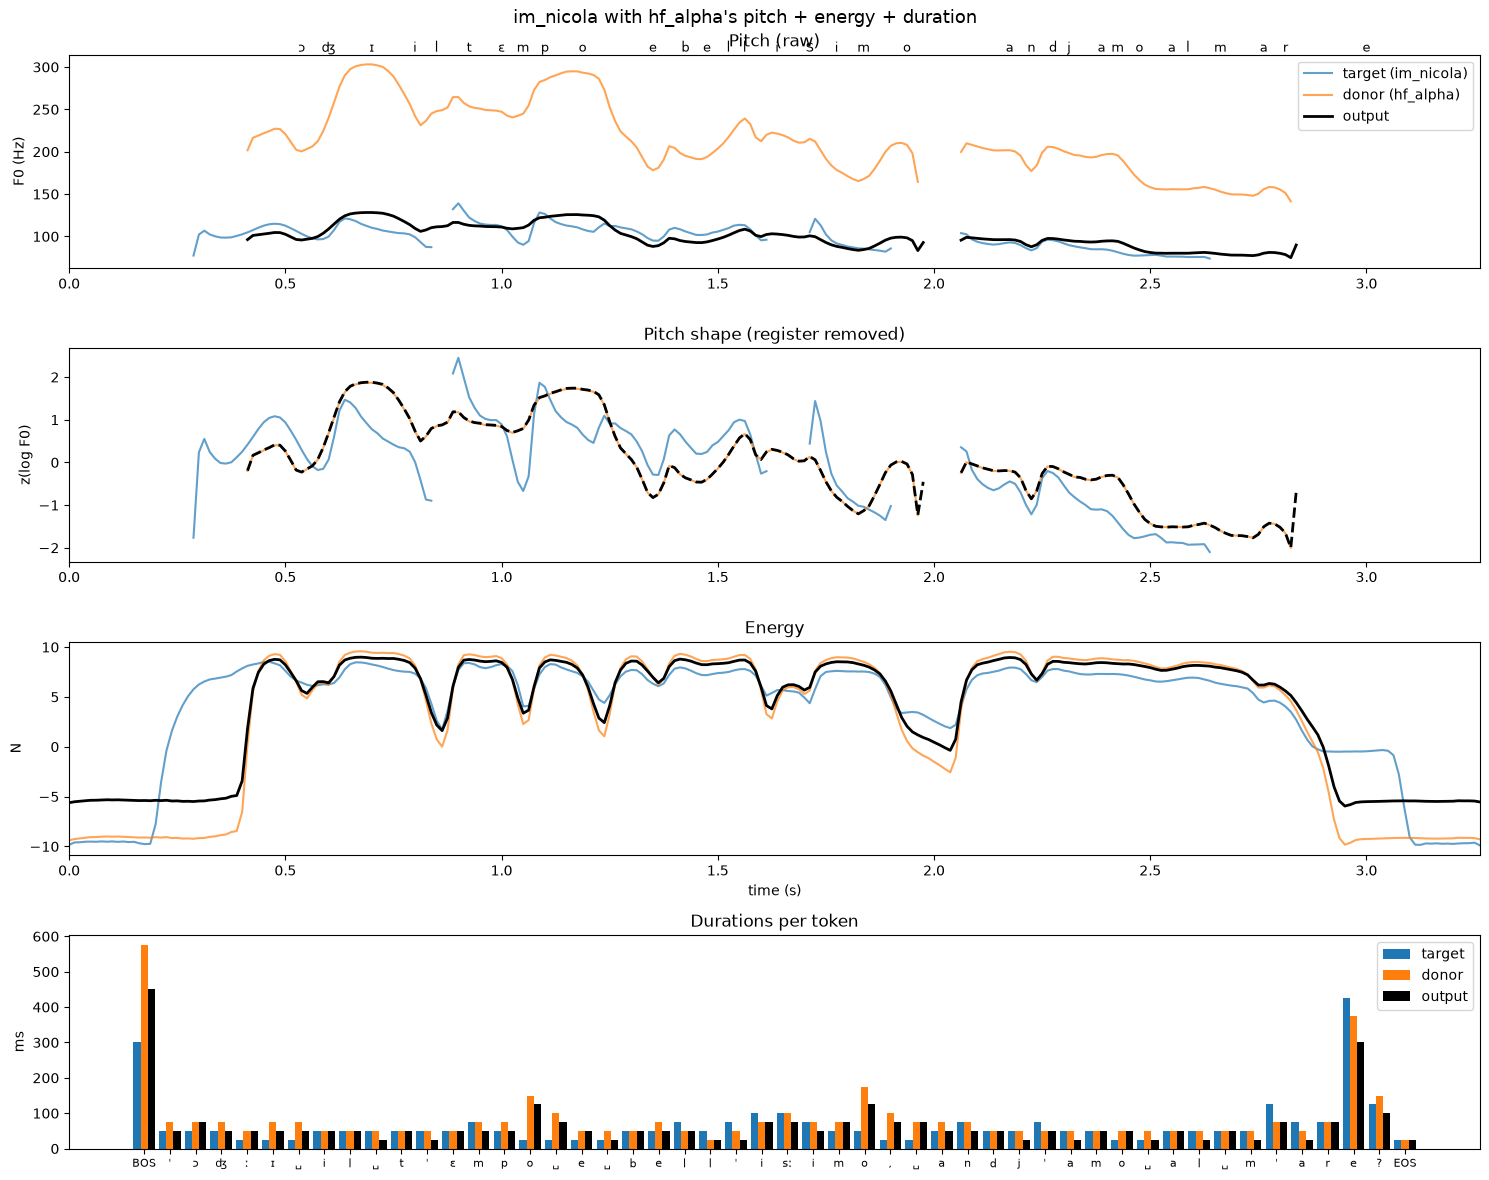

target       F0   98.9 Hz  ± 2.4 st   energy   4.01 ± 5.57   length  3.27 s
donor        F0  209.8 Hz  ± 3.4 st   energy   3.12 ± 7.24   length  4.17 s
output       F0   98.8 Hz  ± 2.4 st   energy   4.01 ± 5.57   length  3.27 s


In [8]:
audio_ped, info_ped = prosody_transfer(ps, target_voice, donor_voice,
                                       pitch=True, energy=True, duration=True,
                                       dur_mode="rate")   # "raw" = also take the donor's tempo
display(Audio(audio_ped, rate=SR))
plot_transfer(info_ped, audio_ped)

## Other combinations
Any mix works, e.g. `pitch=True, energy=False, duration=True`.
Modes: `f0_mode` / `energy_mode` = `"raw"`, `"mean"`, `"meanstd"`; `dur_mode` = `"raw"`, `"rate"`.

# Measuring the prosodic difference: native vs accented

Both conditions share the **same text and the same timbre** (target voice), so every acoustic difference comes from the transferred prosody.

**Time alignment.** Durations are known exactly for both versions, so no DTW is needed. Accented frames are mapped onto the native time axis token by token (piecewise-linear warp between token boundaries). Every frame of the native utterance then has its counterpart in the accented one.

**Continuous error curves** (native time axis, 12.5 ms frames):
- `d_f0_st`: F0 difference in semitones, `12·log2(F0_acc / F0_nat)`, on frames voiced in both versions
- `d_en`: energy difference (dB RMS for `level="acoustic"`, units of Kokoro's N for `level="model"`) on speech frames
- `d_dur_log2`: local tempo, `log2(dur_acc / dur_nat)` of the token the frame belongs to (+1 = twice as long)

**Summaries:** bias (mean error), RMSE, MAE, Pearson r (contour shape similarity), voicing disagreement; per-token table; rhythm metrics (%V, ΔV, ΔC, nPVI-V, rPVI-C).

`level="acoustic"` measures pyin F0 and RMS energy from the audio: what a listener actually hears, and what to report. `level="model"` uses the curves fed to the decoder (exact, no tracking errors).

In [9]:
import pandas as pd
import librosa                        # pip install librosa

HOP   = FRAME_SAMPLES // 2            # 300 samples = 12.5 ms, same rate as Kokoro's F0 / N
HOP_S = HOP / SR
SPEECH_KINDS = ("phone", "diacritic", "stress")


def token_labels(ps):
    labels = ["BOS"] + [c for c in ps if c in VOCAB] + ["EOS"]
    kinds  = ["bos"] + [token_kind(c) for c in labels[1:-1]] + ["eos"]
    return labels, kinds


def token_edges(dur, n_samples):
    """Token boundaries in seconds, len = n_tokens + 1."""
    return np.concatenate([[0], np.cumsum(dur)]) * (n_samples / sum(dur)) / SR


def acoustic_tracks(audio):
    """pyin F0 (Hz, NaN = unvoiced) and RMS energy (dB), one value per 12.5 ms."""
    f0, _, _ = librosa.pyin(audio, fmin=50, fmax=600, sr=SR, frame_length=1200, hop_length=HOP)
    rms = librosa.feature.rms(y=audio, frame_length=1200, hop_length=HOP)[0]
    n = min(len(f0), len(rms))
    return f0[:n], 20 * np.log10(np.maximum(rms[:n], 1e-5))


def model_tracks(info):
    """The F0 / N curves that were fed to the decoder (F0 NaN = unvoiced)."""
    f0 = info["f0"].astype(float).copy()
    f0[~voiced_mask(f0)] = np.nan
    return f0, info["n"].astype(float).copy()


def _tracks(audio, info, level):
    return acoustic_tracks(audio) if level == "acoustic" else model_tracks(info)

In [10]:
def _err_stats(x, y, d):
    """x, y: the two curves; d: their difference. Uses frames where everything is finite."""
    ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(d)
    if ok.sum() < 3:
        return dict(bias=np.nan, rmse=np.nan, mae=np.nan, r=np.nan, n=int(ok.sum()))
    d = d[ok]
    return dict(bias=d.mean(), rmse=np.sqrt((d ** 2).mean()), mae=np.abs(d).mean(),
                r=np.corrcoef(x[ok], y[ok])[0, 1], n=int(ok.sum()))


def compare(native, accented, level="acoustic"):
    """native, accented: (audio, info) tuples from prosody_transfer, same text.
    Returns (frames, tokens, summary):
      frames  : DataFrame, one row per 12.5 ms frame on the NATIVE time axis, with continuous errors
      tokens  : DataFrame, one row per token (durations + mean F0 / energy error inside it)
      summary : dict of scalar measures"""
    (a_n, i_n), (a_a, i_a) = native, accented
    assert i_n["ps"] == i_a["ps"], "both conditions must have the same IPA string"
    labels, kinds = token_labels(i_n["ps"])

    f0_n, en_n = _tracks(a_n, i_n, level)
    f0_a, en_a = _tracks(a_a, i_a, level)

    # native time -> accented time, linear inside each token
    e_n, e_a = token_edges(i_n["dur"], len(a_n)), token_edges(i_a["dur"], len(a_a))
    t   = np.arange(len(f0_n)) * HOP_S
    j   = np.clip(np.round(np.interp(t, e_n, e_a) / HOP_S).astype(int), 0, len(f0_a) - 1)
    f0_aw, en_aw = f0_a[j], en_a[j]

    tok    = np.clip(np.searchsorted(e_n, t, side="right") - 1, 0, len(labels) - 1)
    speech = np.isin(np.array(kinds)[tok], SPEECH_KINDS)
    dlog   = np.log2(np.asarray(i_a["dur"], float) / np.asarray(i_n["dur"], float))

    with np.errstate(divide="ignore", invalid="ignore"):
        d_f0 = 12 * np.log2(f0_aw / f0_n)
    d_en = np.where(speech, en_aw - en_n, np.nan)

    frames = pd.DataFrame(dict(t=t, token=np.array(labels)[tok], tok_idx=tok, speech=speech,
                               f0_native=f0_n, f0_accented=f0_aw, d_f0_st=d_f0,
                               en_native=en_n, en_accented=en_aw, d_en=d_en,
                               d_dur_log2=dlog[tok]))

    ms = lambda d: np.asarray(d, float) * 1000 * FRAME_SAMPLES / SR
    tokens = pd.DataFrame(dict(token=labels, kind=kinds, start_s=e_n[:-1], end_s=e_n[1:],
                               dur_native_ms=ms(i_n["dur"]), dur_accented_ms=ms(i_a["dur"]),
                               d_dur_log2=dlog))
    g = frames.groupby("tok_idx")
    tokens["d_f0_st"] = g["d_f0_st"].mean().reindex(tokens.index)
    tokens["d_en"]    = g["d_en"].mean().reindex(tokens.index)

    # --- scalar summary ---
    sp = speech
    vn, va = np.isfinite(f0_n[sp]), np.isfinite(f0_aw[sp])
    f0s = _err_stats(np.log2(f0_n[sp]), np.log2(f0_aw[sp]), d_f0[sp])
    ens = _err_stats(en_n[sp], en_aw[sp], d_en[sp])
    ph  = tokens["kind"].eq("phone").to_numpy()
    dus = _err_stats(np.log2(ms(i_n["dur"]))[ph], np.log2(ms(i_a["dur"]))[ph], dlog[ph])

    summary = {"level": level}
    summary.update({f"f0_{k}": v for k, v in f0s.items() if k != "n"})
    summary["f0_voicing_disagree"] = float(np.mean(vn != va))
    summary.update({f"en_{k}": v for k, v in ens.items() if k != "n"})
    summary.update({f"dur_{k}": v for k, v in dus.items() if k != "n"})
    summary["length_ratio"] = sum(i_a["dur"]) / sum(i_n["dur"])
    for name, info in [("native", i_n), ("accented", i_a)]:
        summary.update({f"{name}_{k}": v for k, v in rhythm_metrics(info).items()})
    return frames, tokens, summary

In [11]:
def rhythm_metrics(info):
    """Interval-based rhythm metrics from the model durations.
    Vocalic / consonantal intervals: consecutive vowel (or consonant) tokens merged,
    diacritics join the previous phone, stress marks are ignored, word spaces do not
    break intervals, punctuation / BOS / EOS (pauses) do."""
    labels, kinds = token_labels(info["ps"])
    ms = np.asarray(info["dur"], float) * 1000 * FRAME_SAMPLES / SR
    iv, cur, typ = [], 0.0, None                    # list of (type, ms)
    for lab, kind, d in zip(labels, kinds, ms):
        if kind == "phone":
            t = "V" if lab in VOWELS else "C"
            if t != typ and typ is not None:
                iv.append((typ, cur)); cur = 0.0
            typ = t; cur += d
        elif kind == "diacritic" and typ is not None:
            cur += d
        elif kind in ("punct", "bos", "eos") and typ is not None:
            iv.append((typ, cur)); cur, typ = 0.0, None
    if typ is not None:
        iv.append((typ, cur))
    V = np.array([d for t, d in iv if t == "V"]); C = np.array([d for t, d in iv if t == "C"])
    npvi = lambda x: 100 * np.mean(np.abs(np.diff(x)) / ((x[:-1] + x[1:]) / 2)) if len(x) > 1 else np.nan
    rpvi = lambda x: np.mean(np.abs(np.diff(x))) if len(x) > 1 else np.nan
    return {"%V": 100 * V.sum() / (V.sum() + C.sum()), "deltaV": V.std(), "deltaC": C.std(),
            "nPVI_V": npvi(V), "rPVI_C": rpvi(C)}

In [12]:
def plot_compare(frames, tokens, summary, grid=False):
    t = frames["t"].to_numpy()
    en_unit = "dB" if summary["level"] == "acoustic" else "N"
    fig, ax = plt.subplots(5, 1, figsize=(15, 13), sharex=True,
                           gridspec_kw=dict(height_ratios=[2, 1, 2, 1, 1]))

    ax[0].plot(t, frames["f0_native"], label="native")
    ax[0].plot(t, frames["f0_accented"], label="accented (time-aligned)")
    ax[0].set_ylabel("F0 (Hz)"); ax[0].legend(loc="upper right")
    ax[0].set_title(f"F0   bias {summary['f0_bias']:+.2f} st   RMSE {summary['f0_rmse']:.2f} st   "
                    f"r {summary['f0_r']:.2f}   voicing disagreement {100*summary['f0_voicing_disagree']:.0f}%", pad=18)

    ax[1].plot(t, frames["d_f0_st"], color="k"); ax[1].axhline(0, color="gray", lw=.8)
    ax[1].set_ylabel("ΔF0 (st)")

    sp = frames["speech"].to_numpy()
    ax[2].plot(t, np.where(sp, frames["en_native"], np.nan), label="native")
    ax[2].plot(t, np.where(sp, frames["en_accented"], np.nan), label="accented (time-aligned)")
    ax[2].set_ylabel(f"energy ({en_unit})"); ax[2].legend(loc="upper right")
    ax[2].set_title(f"Energy   bias {summary['en_bias']:+.2f}   RMSE {summary['en_rmse']:.2f} {en_unit}   r {summary['en_r']:.2f}")

    ax[3].plot(t, frames["d_en"], color="k"); ax[3].axhline(0, color="gray", lw=.8)
    ax[3].set_ylabel(f"Δenergy ({en_unit})")

    ax[4].step(t, frames["d_dur_log2"], where="post", color="k"); ax[4].axhline(0, color="gray", lw=.8)
    ax[4].set_ylabel("log2 dur ratio"); ax[4].set_xlabel("native time (s)")
    ax[4].set_title(f"Duration (phones)   bias {summary['dur_bias']:+.2f}   RMSE {summary['dur_rmse']:.2f} log2   "
                    f"r {summary['dur_r']:.2f}   total length ×{summary['length_ratio']:.2f}")

    for a in ax:
        a.set_xlim(0, t[-1])
        if grid:
            for s in tokens["start_s"]:
                a.axvline(s, color="gray", lw=.4, alpha=.4)
    top = ax[0].get_ylim()[1]
    for _, r in tokens[tokens["kind"] == "phone"].iterrows():
        ax[0].text((r.start_s + r.end_s) / 2, top, LABEL_DISPLAY.get(r.token, r.token),
                   ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.show()

## Native vs accented

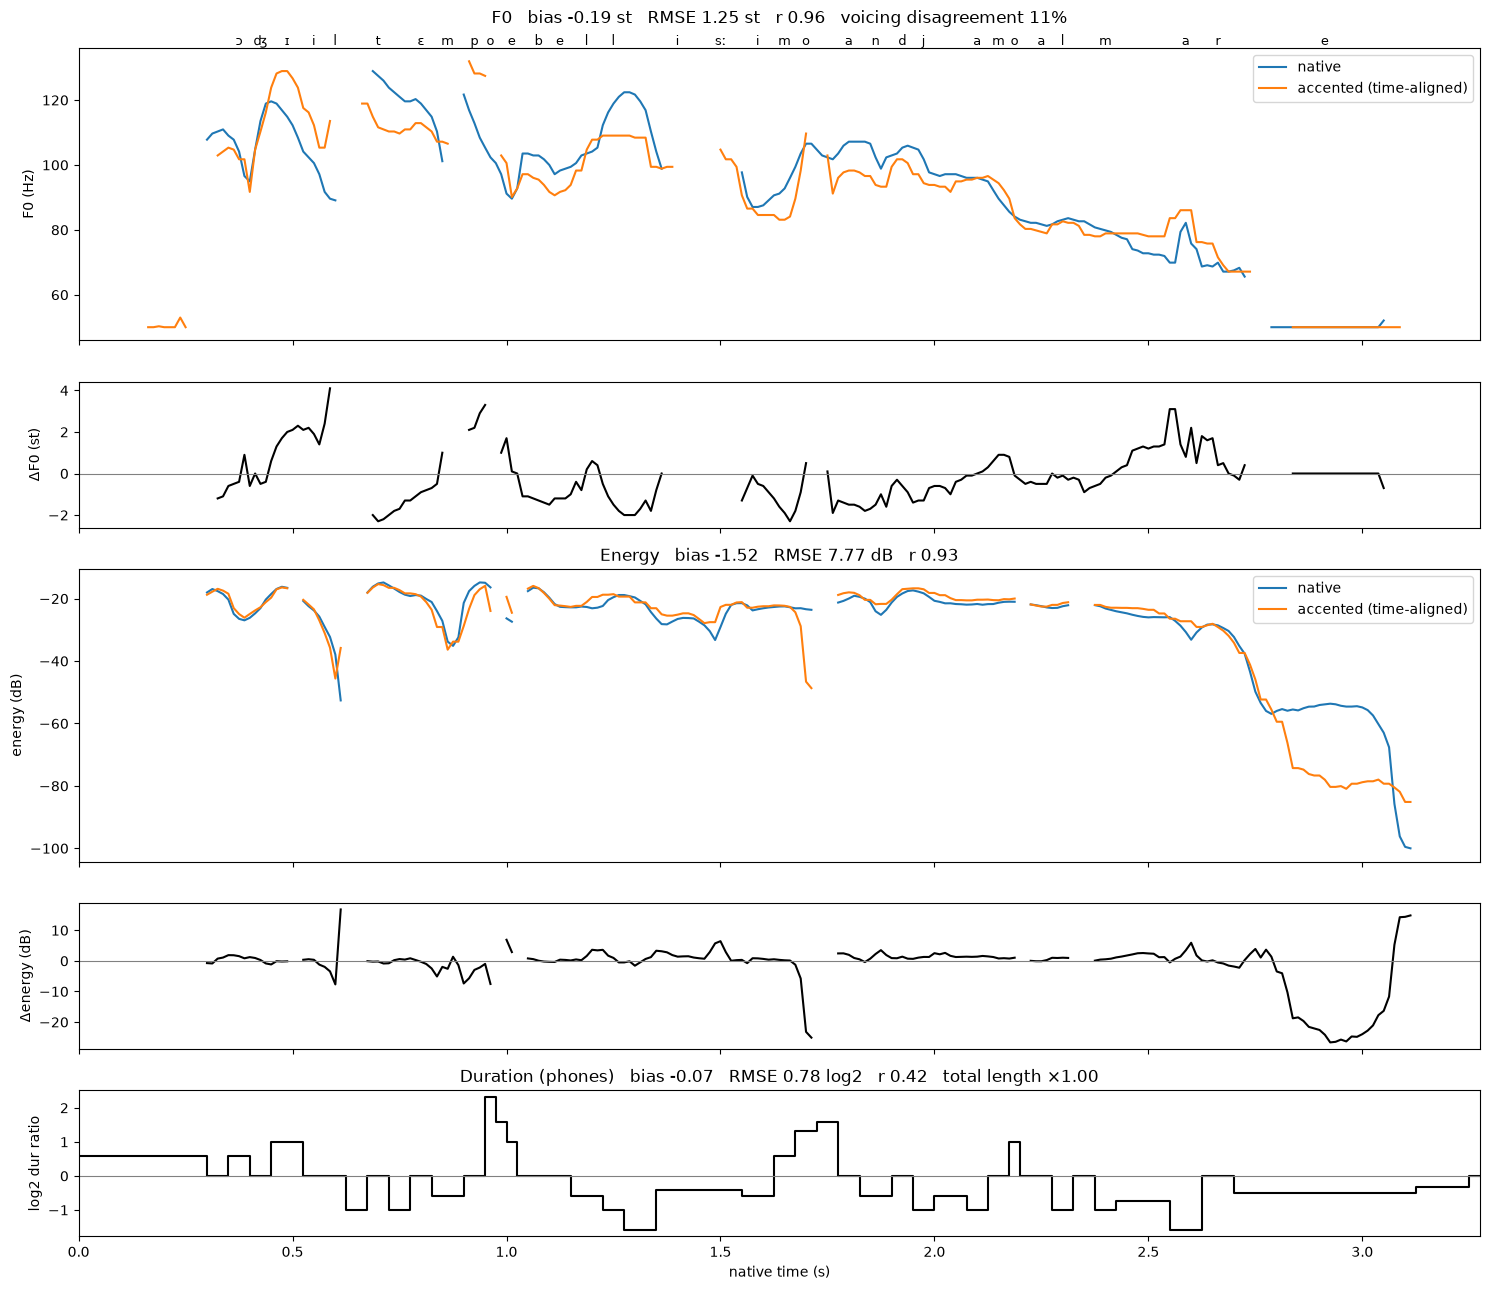

TypeError: type str doesn't define __round__ method

In [13]:
# native  = target voice with its own prosody
# accented = target voice with the donor's (other-language) prosody
native   = prosody_transfer(ps, target_voice, donor_voice, pitch=False, energy=False, duration=False)
accented = prosody_transfer(ps, target_voice, donor_voice, pitch=True,  energy=True,  duration=True)

frames, tokens, summary = compare(native, accented, level="acoustic")   # or level="model"
plot_compare(frames, tokens, summary)
display(pd.Series(summary).round(3).to_frame("value"))
display(tokens[tokens["kind"] == "phone"].round(3))

## Sanity check: does the audio carry the F0 we asked for?
pyin F0 of the output vs the F0 curve fed to the decoder. Small RMSE (well under 1 st) means the acoustic measures above reflect the manipulation, not decoder artifacts.

In [14]:
def realization_error(audio, info):
    f0_meas, _ = acoustic_tracks(audio)
    f0_int, _  = model_tracks(info)
    n = min(len(f0_meas), len(f0_int))
    with np.errstate(divide="ignore", invalid="ignore"):
        d = 12 * np.log2(f0_meas[:n] / f0_int[:n])
    return _err_stats(np.log2(f0_int[:n]), np.log2(f0_meas[:n]), d)

for name, (a, i) in [("native", native), ("accented", accented)]:
    print(name, {k: round(float(v), 3) for k, v in realization_error(a, i).items()})

native {'bias': 0.166, 'rmse': 0.538, 'mae': 0.357, 'r': 0.977, 'n': 154.0}
accented {'bias': 0.086, 'rmse': 0.759, 'mae': 0.49, 'r': 0.96, 'n': 162.0}


## Many sentences → one table
One row per sentence and condition. This is the table to aggregate or put into stats (e.g. mixed models with sentence as a random effect).

In [15]:
texts = [
    "Oggi il tempo è bellissimo, andiamo al mare?",
    "Il treno per Milano parte alle otto.",
    "Non ho capito bene quello che hai detto.",
]
conditions = {                       # name -> what is transferred from the donor
    "pitch+energy":          dict(pitch=True, energy=True, duration=False),
    "pitch+energy+duration": dict(pitch=True, energy=True, duration=True),
}

rows = []
for si, tx in enumerate(texts):
    for ps_i in text_to_ipa_chunks(tx):
        nat = prosody_transfer(ps_i, target_voice, donor_voice, pitch=False, energy=False, duration=False)
        for cname, flags in conditions.items():
            acc = prosody_transfer(ps_i, target_voice, donor_voice, **flags)
            _, _, s = compare(nat, acc, level="acoustic")
            rows.append({"sentence": si, "text": tx, "condition": cname, **s})

results = pd.DataFrame(rows)
display(results.groupby("condition").mean(numeric_only=True).T.round(3))

condition,pitch+energy,pitch+energy+duration
sentence,1.000,1.000
f0_bias,0.099,-0.281
f0_rmse,2.327,1.629
f0_mae,1.633,1.244
f0_r,0.882,0.944
f0_voicing_disagree,0.157,0.110
en_bias,-1.732,-2.022
en_rmse,9.332,7.704
en_mae,4.553,3.916
en_r,0.879,0.937
